#### Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/nimma/Downloads/IDS-PROJECT/dataset/CICIDS2017_Clean.csv')

#### Separate Features and Target

In [5]:
X = df.drop('Label', axis=1)
y = df['Label']

#### Compute Correlation Matrix

In [9]:
corr_matrix = X.corr(method='pearson')

In [10]:
print(corr_matrix.shape)

(70, 70)


#### Visualize Correaltion Heatmap

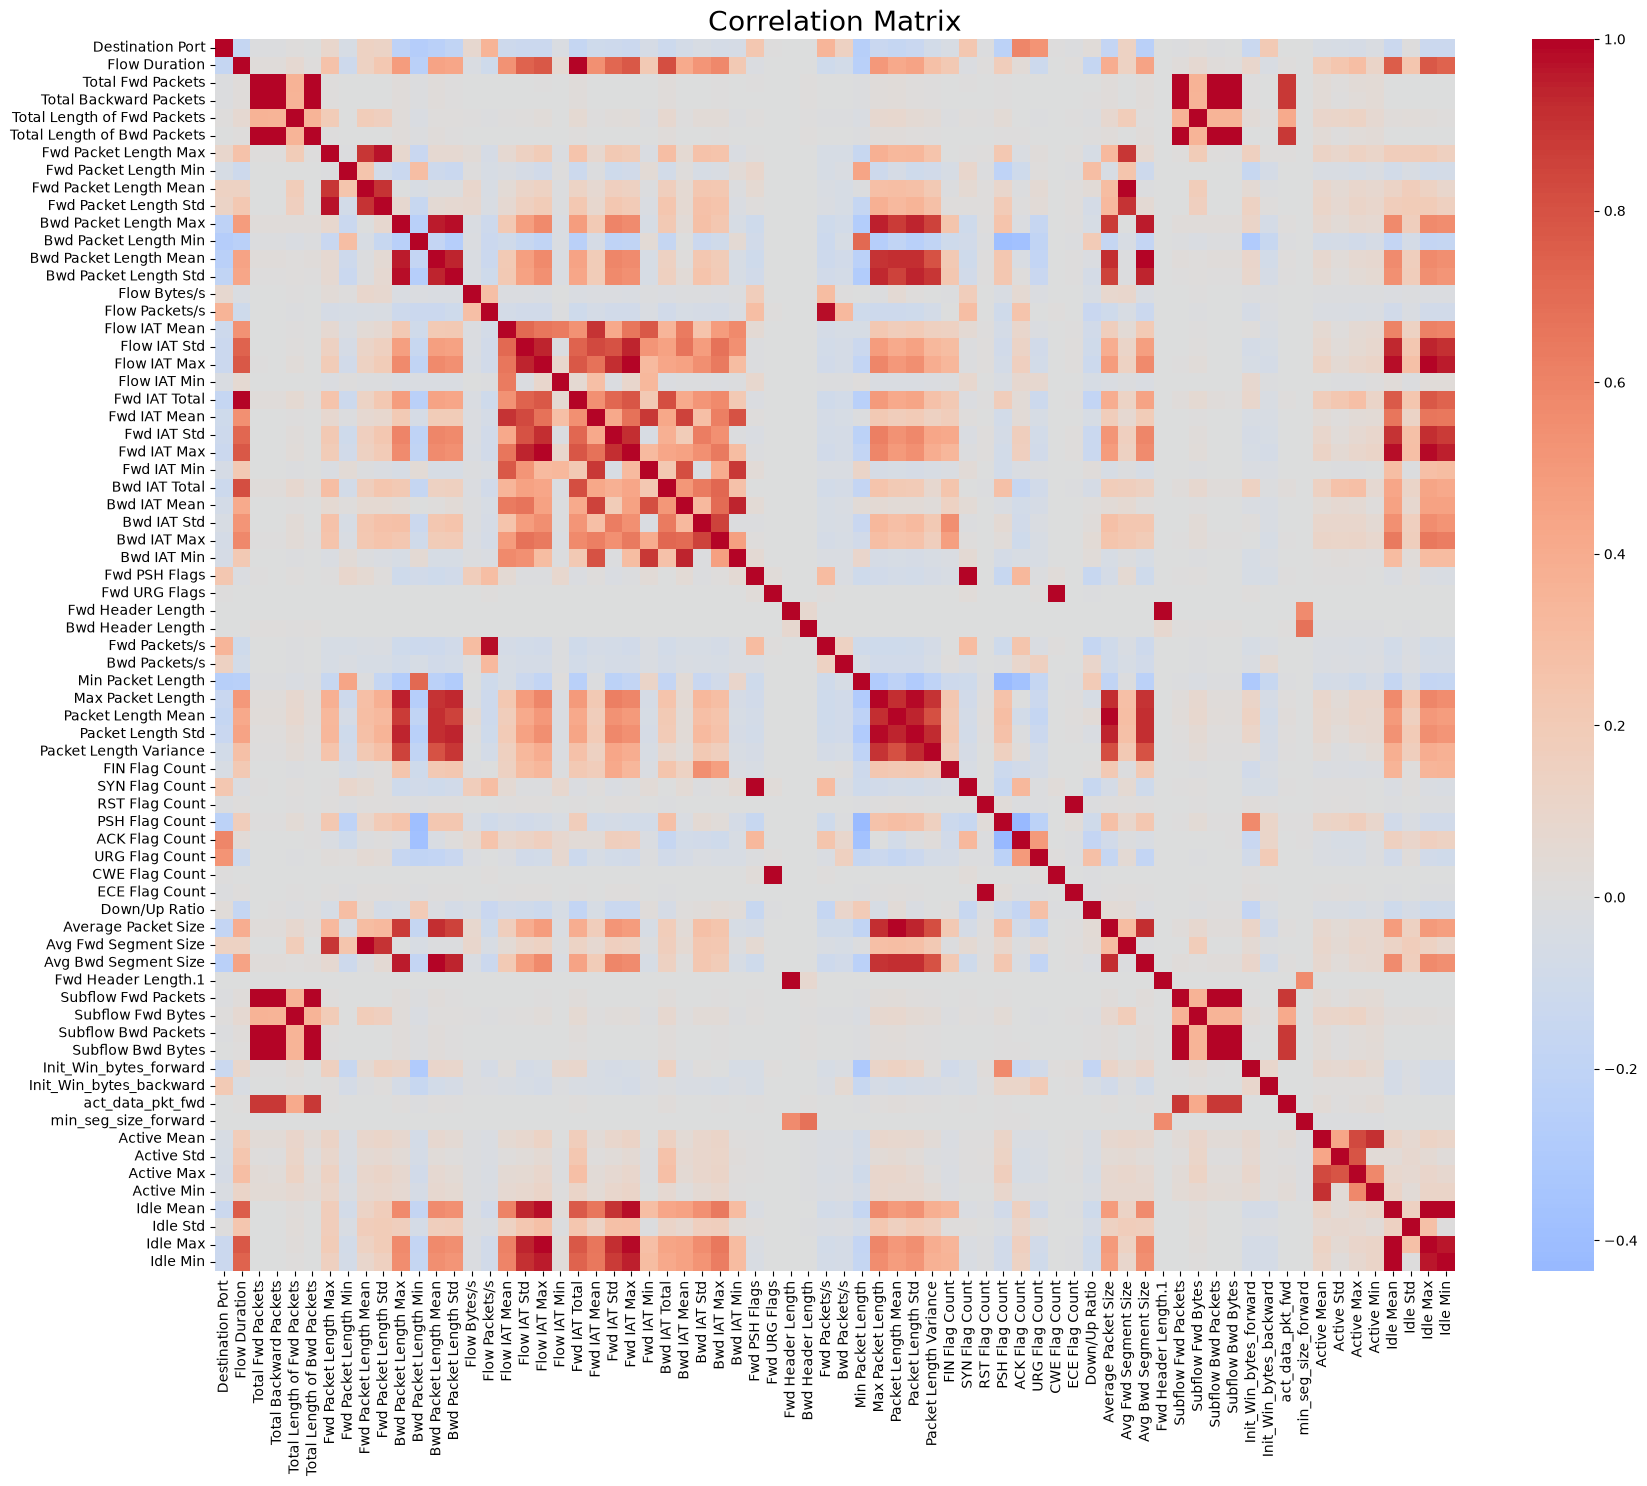

In [14]:
plt.figure(figsize=(20,16))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix', fontsize=20)
plt.show()

#### Identify Highly Correlated Features

In [18]:
threshold = 0.9

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(abs(upper[column]) > threshold)
]

print(f"Number of highly correlated features: {len(high_corr)}")
print("Highly correlated features:")
for feature in high_corr:
    print(f" - {feature}")

Number of highly correlated features: 31
Highly correlated features:
 - Total Backward Packets
 - Total Length of Bwd Packets
 - Fwd Packet Length Std
 - Bwd Packet Length Mean
 - Bwd Packet Length Std
 - Flow IAT Max
 - Fwd IAT Total
 - Fwd IAT Mean
 - Fwd IAT Std
 - Fwd IAT Max
 - Bwd IAT Min
 - Fwd Packets/s
 - Max Packet Length
 - Packet Length Mean
 - Packet Length Std
 - Packet Length Variance
 - SYN Flag Count
 - CWE Flag Count
 - ECE Flag Count
 - Average Packet Size
 - Avg Fwd Segment Size
 - Avg Bwd Segment Size
 - Fwd Header Length.1
 - Subflow Fwd Packets
 - Subflow Fwd Bytes
 - Subflow Bwd Packets
 - Subflow Bwd Bytes
 - Active Min
 - Idle Mean
 - Idle Max
 - Idle Min


#### Remove Highly Correlated Features

In [19]:
X_reduced = X.drop(columns=high_corr)

print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of features: {X_reduced.shape[1]}")

Original number of features: 70
Reduced number of features: 39


#### Save the Reduced Dataset

In [20]:
df_reduced = pd.concat([X_reduced,y],axis=1)

df_reduced.to_csv(
    'C:/Users/nimma/Downloads/IDS-PROJECT/dataset/CICIDS2017_FeatureSelected.csv',
    index=False
)

#### Feature Importance (RF)

In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_reduced, y_encoded)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

#### Rank Features

In [23]:
importance = pd.DataFrame({
    "Feature": X_reduced.columns,
    "Importance":  rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 25 most important features:")
for i, row in importance.head(25).iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")


Top 25 most important features:
Bwd Packet Length Max: 0.1415
Total Length of Fwd Packets: 0.0646
Flow IAT Std: 0.0611
Flow IAT Mean: 0.0540
Fwd Packet Length Max: 0.0527
Flow Packets/s: 0.0494
act_data_pkt_fwd: 0.0455
Fwd Packet Length Mean: 0.0455
Fwd Header Length: 0.0404
Destination Port: 0.0395
Bwd Header Length: 0.0336
Total Fwd Packets: 0.0323
PSH Flag Count: 0.0317
Bwd Packets/s: 0.0303
Flow Duration: 0.0300
Init_Win_bytes_backward: 0.0267
min_seg_size_forward: 0.0254
Init_Win_bytes_forward: 0.0233
Flow Bytes/s: 0.0233
ACK Flag Count: 0.0174
Fwd IAT Min: 0.0162
Fwd Packet Length Min: 0.0142
Bwd Packet Length Min: 0.0138
Bwd IAT Max: 0.0110
Bwd IAT Std: 0.0093


#### Plot Top 20 Features

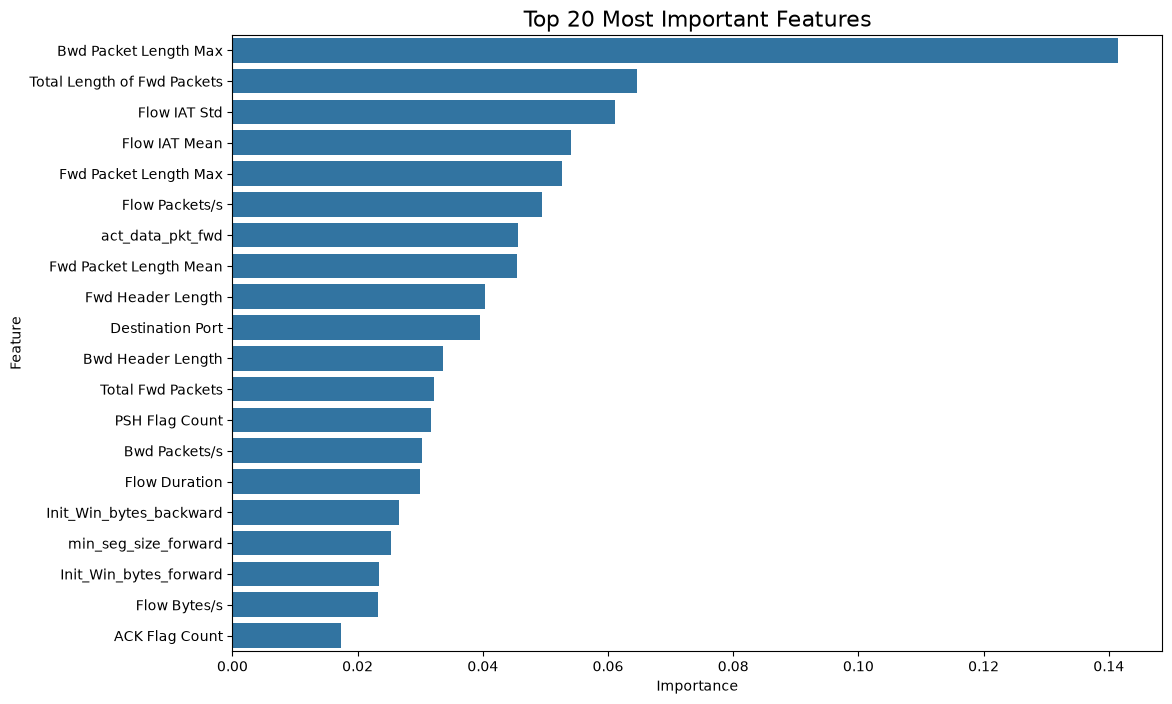

In [24]:
top20 = importance.head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature",
)

plt.title("Top 20 Most Important Features", fontsize=16)
plt.show()